In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

grid_features = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\grid_final_feature_set.csv")
grid_full = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\grid_data_final_preprocessed_15min.csv")

grid_features = grid_features.reset_index(drop=True)
grid_full = grid_full.reset_index(drop=True)

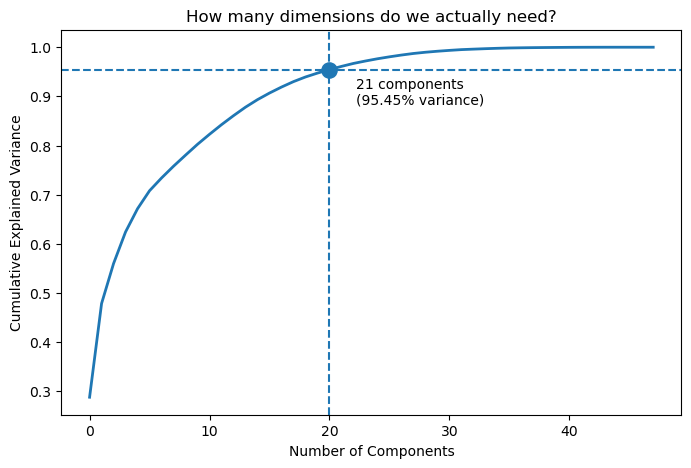

Optimal number of components: 21


In [5]:
# PCA for dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(grid_features)

pca = PCA()
pca.fit(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

threshold = 0.95
n_components = np.argmax(cum_var >= threshold) + 1

plt.figure(figsize=(8,5))
plt.plot(cum_var, linewidth=2)

plt.scatter(n_components-1, cum_var[n_components-1], s=120)
plt.axvline(n_components-1, linestyle='--')
plt.axhline(cum_var[n_components-1], linestyle='--')

plt.text(
    n_components + 1.2, 
    cum_var[n_components-1] - 0.015,
    f"{n_components} components\n({cum_var[n_components-1]*100:.2f}% variance)",
    fontsize=10,
    verticalalignment='top'
)

plt.title("How many dimensions do we actually need?")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()
print("Optimal number of components:", n_components)

In [6]:
#Using VIF for feature selection
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

X = grid_features.copy()
X = X.dropna()  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = list(grid_features.columns)
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(len(list(grid_features.columns)))]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

c:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                        Feature         VIF
0                        temp_c         inf
6                 demand_avg_mw         inf
5                   wind_gen_mw         inf
4                  solar_gen_mw         inf
37                    wind_ramp         inf
38               renewable_ramp         inf
30         heating_degree_hours         inf
29         cooling_degree_hours         inf
36                   solar_ramp         inf
47                  net_load_mw         inf
15            solar_penetration  600.841165
16  total_renewable_penetration  514.276133
11                demand_lag_1h  286.703258
13              temp_rolling_3h  223.771450
20              net_load_lag_1h  118.414230
35                net_load_ramp   65.608978
21                 temp_lag_24h   56.482290
12             net_load_lag_24h   54.119254
18               demand_lag_24h   48.886396
26          temp_rolling_max_3d   42.346196
25         temp_rolling_mean_7d   38.026500
10                  demand_ramp 

In [9]:
if_features_final = [
    'net_load_ramp',
    'demand_ramp',
    'solar_ramp',
    'wind_ramp',
    'demand_volatility_6h',
    'solar_penetration',
    'heat_index_c',
    'heatwave_index',
    'humidity_pct',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'demand_rolling_std_7d',
    'demand_rolling_max_24h',
    'is_weekend',
    'is_peak_hour',
    'low_ren_high_dem',
    'is_extreme_temp',
    'is_extreme_demand',
    'dhi_wm2',
]

X = grid_features[if_features_final].copy()
print(f"\nFinal dataset shape: {X.shape}")


Final dataset shape: (105216, 21)


In [13]:
# Isolation Forest
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if_model = IsolationForest(
    contamination=0.05,  
    n_estimators=100,
    random_state=42,
    n_jobs=-1  
)

if_model.fit(X_scaled)
predictions = if_model.predict(X_scaled)
scores = if_model.decision_function(X_scaled)

anomalies_df = X.loc[X.index].copy()  
anomalies_df['if_anomaly_flag'] = (predictions == -1).astype(int)  
anomalies_df['if_anomaly_score'] = scores

anomalies_df = anomalies_df[anomalies_df['if_anomaly_flag'] == 1].copy()

print(f"Total rows: {len(anomalies_df)}")
print(f"Anomalies found: {len(anomalies_df)}")
print(f"Percentage: {len(anomalies_df)/len(X)*100:.2f}%")

Total rows: 5261
Anomalies found: 5261
Percentage: 5.00%
